# Model Training

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

SEED = 42

### Carregando e visualizando a base

In [2]:
# =========================================
# Carregamento da base tratada
# =========================================

# Ajuste o caminho conforme sua estrutura
df = pd.read_csv("../data/klike_challenge_clear.csv")

print("Shape da base:", df.shape)
df.head()

Shape da base: (500, 26)


,campaign_id,date,platform,category,objective,target_audience_age,is_retargeting,video_duration_s,format,has_subtitle,...,clicks,ctr,cpc,spend,conversions,revenue,roas,avg_watch_time_s,engagement_rate,klike_score
0,KLK-0001,2024-01-01,Meta,Branding,awareness,18-24,False,16.0,vertical,True,...,5882,0.0390,0.82,4823.24,48,0.0000,0.00,3.9,0.0446,63.6
1,KLK-0002,2024-03-22,LinkedIn,App Install,traffic,25-34,False,16.0,horizontal,True,...,493,0.0664,3.54,1745.22,34,279.2352,0.16,6.4,0.0217,70.0
2,KLK-0003,2024-05-04,TikTok,SaaS,traffic,25-34,False,8.0,vertical,True,...,15069,0.0780,0.38,5726.22,492,51053.4400,8.92,8.0,0.1000,99.1
3,KLK-0004,2024-12-27,TikTok,Lead Gen,engagement,25-34,False,27.0,quadrado,False,...,601,0.0925,0.71,426.71,19,1113.7800,2.61,20.3,0.0414,74.9
4,KLK-0005,2024-07-10,Meta,Branding,engagement,25-34,False,34.0,vertical,True,...,2355,0.0369,0.38,894.90,13,0.0000,0.00,34.0,0.0184,77.9


### Checagem geral dos dados

In [3]:
# =========================================
# Checagem rápida da base
# =========================================

display(df.info())

print("\nValores nulos por coluna:")
print(df.isnull().sum().sort_values(ascending=False))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   campaign_id          500 non-null    object 
 1   date                 500 non-null    object 
 2   platform             500 non-null    object 
 3   category             500 non-null    object 
 4   objective            500 non-null    object 
 5   target_audience_age  500 non-null    object 
 6   is_retargeting       500 non-null    bool   
 7   video_duration_s     500 non-null    float64
 8   format               500 non-null    object 
 9   has_subtitle         500 non-null    object 
 10  has_cta              500 non-null    bool   
 11  has_hook             500 non-null    bool   
 12  has_face             500 non-null    bool   
 13  text_density         500 non-null    object 
 14  music_voice_ratio    500 non-null    float64
 15  impressions          500 non-null    int

None


Valores nulos por coluna:
campaign_id            0
date                   0
engagement_rate        0
avg_watch_time_s       0
roas                   0
revenue                0
conversions            0
spend                  0
cpc                    0
ctr                    0
clicks                 0
impressions            0
music_voice_ratio      0
text_density           0
has_face               0
has_hook               0
has_cta                0
has_subtitle           0
format                 0
video_duration_s       0
is_retargeting         0
target_audience_age    0
objective              0
category               0
platform               0
klike_score            0
dtype: int64


## Etapa pré-treinamento

As features que serão utilizadas foram selecionadas, criando-se o DataFrame 'X' e para target 'y'. 

As campanhas que tiverem "has_subtitle" desconhecido serão tratadas como 'False'.

Os demais booleanos serão convertidos para inteiros.

In [4]:
features = [
    "has_hook", "has_face", "has_cta", "has_subtitle", "is_retargeting",  # booleans
    "format", "platform", "objective", "category",                          # nominais
    "text_density", "target_audience_age",                                  # ordinais
    "video_duration_s", "music_voice_ratio",                                # numéricas
]
TARGET = "klike_score"

# Tipos por grupo de tratamento
bool_features     = ["has_hook", "has_face", "has_cta", "has_subtitle", "is_retargeting"]
nominal_features  = ["format", "platform", "objective", "category"]
ordinal_features  = ["text_density", "target_audience_age"]
numeric_features  = ["video_duration_s", "music_voice_ratio"]

# Ordem das categorias ordinais (do menor para o maior)
text_density_order    = ["low", "medium", "high"]
age_order             = ["18-24", "25-34", "35-44", "45+"]

X = df[features].copy()
y = df[TARGET].copy()

# has_subtitle tem 'unknown' — trata separado
X["has_subtitle"] = X["has_subtitle"].map({'True': 1, 'False': 0, 'unknown': 0}).astype(int)

# Demais booleans são dtype=bool nativos — converte direto
pure_bools = ["has_hook", "has_face", "has_cta", "is_retargeting"]
X[pure_bools] = X[pure_bools].astype(int)

Criando o 'preprocessador' que fará o tratamento dos dados para passar para o treinamento.

- 'bools' já foram tratados
- 'nominais' será feito o OneHotEncoder
- 'ordinais' serão adequadas a partir de suas ordens
- 'numerics' foi utilizado o StandardScaler para padronizar as escalas (especialmente para o Ridge)

In [5]:
preprocessor = ColumnTransformer(transformers=[
    ("bool",    "passthrough",                              bool_features),
    ("nominal", OneHotEncoder(drop="first", sparse_output=False), nominal_features),
    ("ordinal", OrdinalEncoder(categories=[text_density_order, age_order]), ordinal_features),
    ("numeric", StandardScaler(),                           numeric_features),
])

Definindo os modelos que usaremos:

- **Ridge Regression**: Regressão Linear com a incorporação de regularização para evitar o risco de overfitting e melhorar a estabilidade dos coeficientes, especialmente no nosso caso com variáveis categóricas codificadas (one-hot encoding)

- **Random Forest**: Diferentemente dos modelos lineares, ele não assume uma forma funcional específica, sendo mais flexível para modelar padrões nos dados. Além disso, é robusto a outliers e não requer padronização das variáveis.

- **XGBoost**: Sua utilização visa explorar ganhos adicionais de performance em relação aos modelos anteriores, especialmente em cenários com interações não lineares entre variáveis.

In [6]:
models = {
    "Ridge (baseline)": Pipeline([
        ("prep", preprocessor),
        ("model", Ridge(alpha=1.0))
    ]),
    "Random Forest": Pipeline([
        ("prep", preprocessor),
        ("model", RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1))
    ]),
    "XGBoost": Pipeline([
        ("prep", preprocessor),
        ("model", xgb.XGBRegressor(n_estimators=200, learning_rate=0.05,
                                    max_depth=5, random_state=SEED,
                                    verbosity=0))
    ]),
}

## Treinamento

Fazendo validação cruzada para cada modelo

In [7]:
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
results = {}

for name, pipe in models.items():
    rmse_scores = cross_val_score(pipe, X, y, cv=cv,
                                  scoring="neg_root_mean_squared_error")
    r2_scores   = cross_val_score(pipe, X, y, cv=cv, scoring="r2")
    results[name] = {
        "RMSE": -rmse_scores.mean(),
        "RMSE_std": rmse_scores.std(),
        "R2": r2_scores.mean(),
        "R2_std": r2_scores.std(),
    }
    print(f"{name}: RMSE={-rmse_scores.mean():.2f} ± {rmse_scores.std():.2f} | R²={r2_scores.mean():.3f}")

Ridge (baseline): RMSE=10.03 ± 0.50 | R²=0.580
Random Forest: RMSE=9.83 ± 0.90 | R²=0.594
XGBoost: RMSE=9.81 ± 0.88 | R²=0.597


Entre os modelos, XGBoost apresentou o melhor desempenho, apesar de estar bem parelho com os outros ainda.

Decidiu-se utilizar o XGBoost, por ser mais promissor em atingir o melhor desempenho, para achar os melhores parâmetros. 

In [8]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "model__n_estimators":     [100, 200, 300, 500],
    "model__max_depth":        [3, 4, 5, 6, 8],
    "model__learning_rate":    [0.01, 0.05, 0.1, 0.2],
    "model__subsample":        [0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
    "model__min_child_weight": [1, 3, 5],
}

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

search = RandomizedSearchCV(
    estimator=models["XGBoost"],
    param_distributions=param_dist,
    n_iter=50,
    scoring="neg_root_mean_squared_error",
    cv=KFold(n_splits=5, shuffle=True, random_state=SEED),
    random_state=SEED,
    n_jobs=-1,
    verbose=1,
)
search.fit(X_train, y_train)

final_model = search.best_estimator_  # este é o modelo que vamos usar daqui pra frente
print(f"Melhores parâmetros: {search.best_params_}")
print(f"Melhor RMSE (CV): {-search.best_score_:.2f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits


Melhores parâmetros: {'model__subsample': 0.8, 'model__n_estimators': 200, 'model__min_child_weight': 1, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.6}
Melhor RMSE (CV): 9.03


Os melhores parâmetros achados fonereceram um modelo com RSME de 9.03 na validação cruzada

### Desempenho do modelo

=== XGBoost Tunado — Test set ===
RMSE : 9.20
MAE  : 7.42
R²   : 0.626


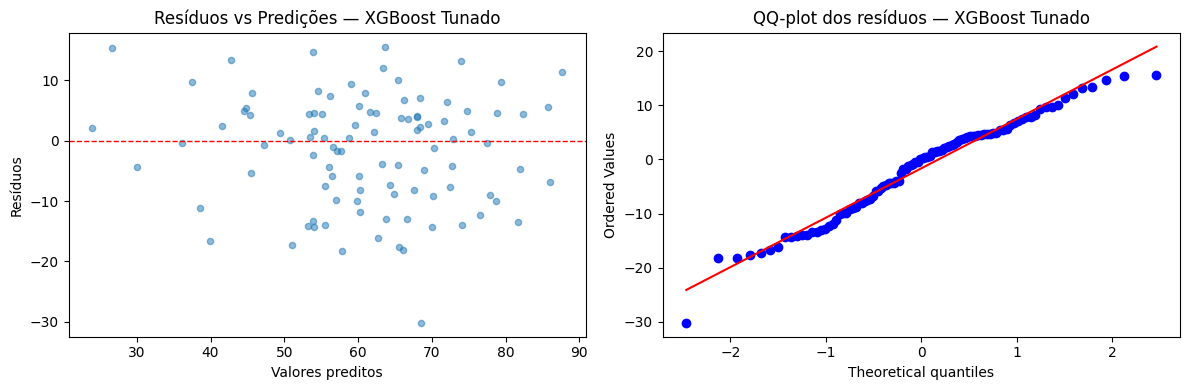

In [9]:
y_pred_final = final_model.predict(X_test)

print("=== XGBoost Tunado — Test set ===")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_final)):.2f}")
print(f"MAE  : {mean_absolute_error(y_test, y_pred_final):.2f}")
print(f"R²   : {r2_score(y_test, y_pred_final):.3f}")

residuals = y_test - y_pred_final
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_pred_final, residuals, alpha=0.5, s=20)
axes[0].axhline(0, color="red", linestyle="--", linewidth=1)
axes[0].set_xlabel("Valores preditos")
axes[0].set_ylabel("Resíduos")
axes[0].set_title("Resíduos vs Predições — XGBoost Tunado")

from scipy import stats
stats.probplot(residuals, plot=axes[1])
axes[1].set_title("QQ-plot dos resíduos — XGBoost Tunado")
plt.tight_layout()
plt.show()

O modelo atingiu um RMSE de 9.2, significando que o modelo erra em média 9.2 pontos para cima ou para baixo na escala de 0-100, um MAE DE 7.42, ou seja, ou erro típico é de 7 pontos e um R² de 0.626, ou seja, o modelo está explicando 62.6% da variância do klike_score.

### Feature Importance

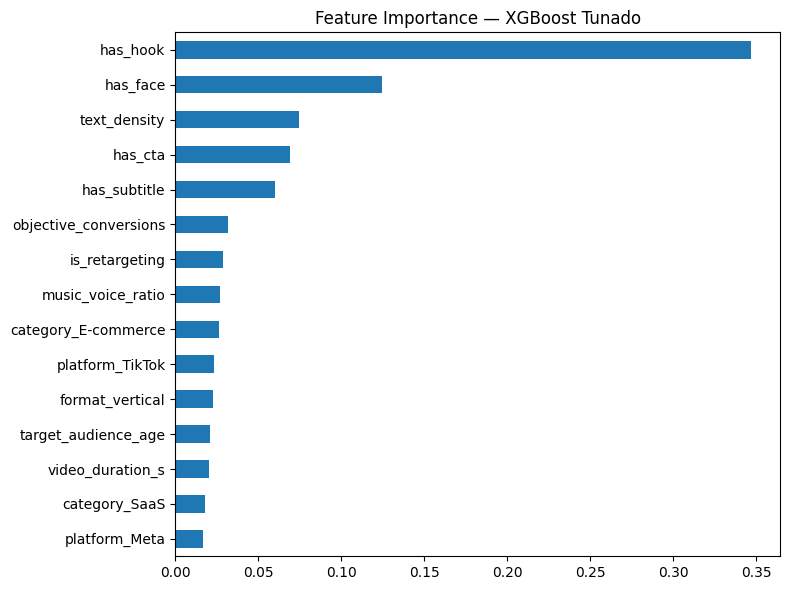

In [10]:
prep = final_model.named_steps["prep"]
xgb_step = final_model.named_steps["model"]

ohe_names = prep.named_transformers_["nominal"].get_feature_names_out(nominal_features).tolist()
all_feature_names = bool_features + ohe_names + ordinal_features + numeric_features

importances = pd.Series(xgb_step.feature_importances_, index=all_feature_names)
importances.sort_values().tail(15).plot(kind="barh", figsize=(8, 6),
                                         title="Feature Importance — XGBoost Tunado")
plt.tight_layout()
plt.show()

Entendendo o que o modelo está levando em consideração, percebemos que a presença de hook é a feature mais relevante na previsão, o que confirma o que foi observado na etapa de análise exploratória. Em seguida, a presença de rosto aparece como a segunda mais relevante para o modelo, confirmando novamente o que foi visto na análise da etapa anterior acerca da importância humanização do conteúdo.

Depois dessas, a quantidade de texto na tela, a presença de call-to-action e legendas seguem como a as mais importantes para descrever o comportamento de klike_score. 

### Análise de Multicolinearidade

In [11]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Pega só as features numéricas e ordinais após encoding
prep = final_model.named_steps["prep"]
X_transformed = prep.transform(X)

# VIF só faz sentido para features contínuas/ordinais (últimas 4 colunas)
vif_features = ordinal_features + numeric_features
n_bool    = len(bool_features)
n_nominal = len(prep.named_transformers_["nominal"].get_feature_names_out(nominal_features))

X_vif = X_transformed[:, n_bool + n_nominal:]

vif_df = pd.DataFrame({
    "feature": vif_features,
    "VIF": [variance_inflation_factor(X_vif, i) for i in range(X_vif.shape[1])]
})
print(vif_df.sort_values("VIF", ascending=False))

               feature       VIF
1  target_audience_age  1.496192
0         text_density  1.493579
2     video_duration_s  1.006392
3    music_voice_ratio  1.006387


O VIF de todas as variáveis numéricas está abaixo de 2, ou seja, praticamente não há multicolinearidade, as features são independentes entre si.

### Distribuição do target

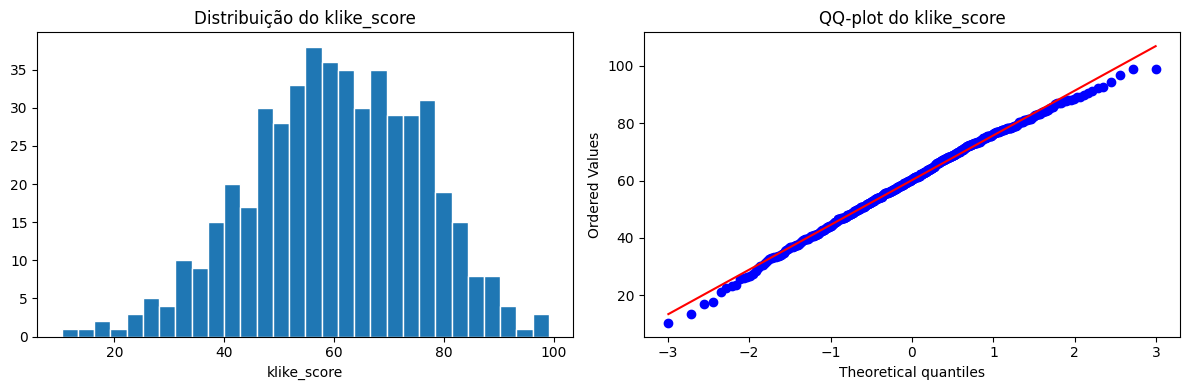

Skewness : -0.225
Kurtosis : -0.137
Min: 10.4 | Max: 99.1 | Média: 60.2 | Mediana: 60.5


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y, bins=30, edgecolor="white")
axes[0].set_title("Distribuição do klike_score")
axes[0].set_xlabel("klike_score")

stats.probplot(y, plot=axes[1])
axes[1].set_title("QQ-plot do klike_score")

plt.tight_layout()
plt.show()

print(f"Skewness : {y.skew():.3f}")
print(f"Kurtosis : {y.kurt():.3f}")
print(f"Min: {y.min()} | Max: {y.max()} | Média: {y.mean():.1f} | Mediana: {y.median():.1f}")

Com o Skewness de -0.225 temos que `klike_score` é praticamente simétrico, a distribuição cobre bem toda a escala 10-99, a média e mediana são quase idênticas e o QQ-plot possui desvios apenas nas caudas, ou seja, comportamento normal.

### Curva de aprendizado

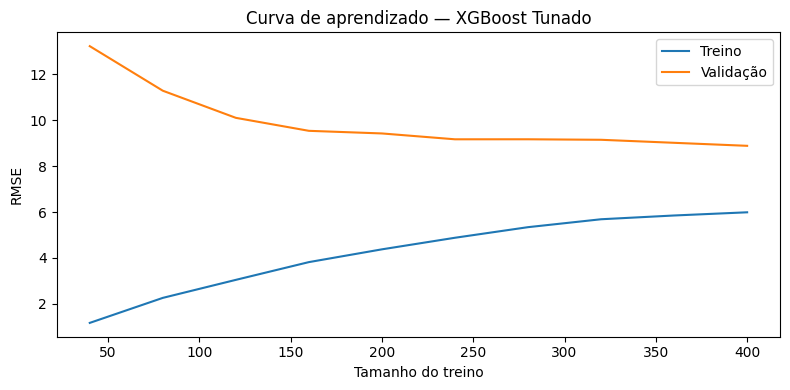

In [13]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    final_model, X, y,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=KFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

train_rmse = -train_scores.mean(axis=1)
val_rmse   = -val_scores.mean(axis=1)

plt.figure(figsize=(8, 4))
plt.plot(train_sizes, train_rmse, label="Treino")
plt.plot(train_sizes, val_rmse,   label="Validação")
plt.xlabel("Tamanho do treino")
plt.ylabel("RMSE")
plt.title("Curva de aprendizado — XGBoost Tunado")
plt.legend()
plt.tight_layout()
plt.show()

O gap entre treino e validação é considerável e as curvas não convergiram completamente, a validação ainda estava caindo quando os dados acabaram. Isso indica que o modelo tem algum overfitting residual e mais dados provavelmente melhorariam a performance. Logo, é importante pontuar que o modelo deve se beneficiar de um dataset maior em produção.

### Salvando o modelo

In [14]:
import joblib
joblib.dump(final_model, "../models/RF.pkl")
print("Modelo salvo!")

Modelo salvo!


### Adicionando novas features

Na análise exploratória, foi observada algumas relações importantes como a existência de rook e sua relação entre plataformas, assim como a presença de rosto humano e plataformas e também legendas. Também foram encontradas durações consideradas ideais para cada plataforma. 

Pensando nisso, vamos adicionar algumas features para tentar melhorar o modelo que obtemos anteriormente.

In [16]:
def add_interaction_features(df_input):
    df_fe = df_input.copy()
    
    # Interações hook × plataforma
    df_fe["hook_tiktok"]   = ((df_fe["has_hook"] == 1) & (df_fe["platform"] == "TikTok")).astype(int)
    df_fe["hook_linkedin"] = ((df_fe["has_hook"] == 1) & (df_fe["platform"] == "LinkedIn")).astype(int)
    df_fe["hook_meta"]     = ((df_fe["has_hook"] == 1) & (df_fe["platform"] == "Meta")).astype(int)

    # Interações face × faixa etária
    df_fe["face_2534"] = ((df_fe["has_face"] == 1) & (df_fe["target_audience_age"] == "25-34")).astype(int)
    df_fe["face_1824"] = ((df_fe["has_face"] == 1) & (df_fe["target_audience_age"] == "18-24")).astype(int)

    # Interações face × plataforma
    df_fe["face_linkedin"] = ((df_fe["has_face"] == 1) & (df_fe["platform"] == "LinkedIn")).astype(int)
    df_fe["face_tiktok"]   = ((df_fe["has_face"] == 1) & (df_fe["platform"] == "TikTok")).astype(int)

    # Subtitle × plataforma (legenda é crítica no LinkedIn)
    df_fe["subtitle_linkedin"] = ((df_fe["has_subtitle"] == 1) & (df_fe["platform"] == "LinkedIn")).astype(int)

    # Score de qualidade combinado (quantos atributos positivos o criativo tem)
    df_fe["creative_quality_score"] = (
        df_fe["has_hook"] + df_fe["has_face"] +
        df_fe["has_cta"] + df_fe["has_subtitle"]
    )

    # Duração adequada por plataforma
    df_fe["duration_fit"] = 0
    df_fe.loc[(df_fe["platform"] == "TikTok")   & (df_fe["video_duration_s"].between(16, 30)), "duration_fit"] = 1
    df_fe.loc[(df_fe["platform"] == "Meta")     & (df_fe["video_duration_s"] <= 15),            "duration_fit"] = 1
    df_fe.loc[(df_fe["platform"] == "LinkedIn") & (df_fe["video_duration_s"] >= 60),            "duration_fit"] = 1

    return df_fe

df_temp = df.copy()
df_temp["has_subtitle"] = df_temp["has_subtitle"].map(
    {'True': 1, 'False': 0, 'unknown': 0, True: 1, False: 0}).astype(int)
df_temp[["has_hook", "has_face", "has_cta", "is_retargeting"]] = \
    df_temp[["has_hook", "has_face", "has_cta", "is_retargeting"]].astype(int)

df_fe = add_interaction_features(df_temp)

print(f"Features originais: {len(features)}")

new_features = [
    "hook_tiktok", "hook_linkedin", "hook_meta",
    "face_2534", "face_1824", "face_linkedin", "face_tiktok",
    "subtitle_linkedin",
    "creative_quality_score",
    "duration_fit",
]
features_fe = features + new_features
print(f"Features com engenharia: {len(features_fe)}")
print(f"Novas features: {new_features}")

Features originais: 13
Features com engenharia: 23
Novas features: ['hook_tiktok', 'hook_linkedin', 'hook_meta', 'face_2534', 'face_1824', 'face_linkedin', 'face_tiktok', 'subtitle_linkedin', 'creative_quality_score', 'duration_fit']


### Treinando um novo modelo com as features adicionais

In [18]:

# Atualiza os grupos de features para o preprocessador
bool_features_fe    = bool_features + new_features  # todas já são 0/1
numeric_features_fe = numeric_features  # inalterado
ordinal_features_fe = ordinal_features  # inalterado
nominal_features_fe = nominal_features  # inalterado

preprocessor_fe = ColumnTransformer(transformers=[
    ("bool",    "passthrough",                                          bool_features_fe),
    ("nominal", OneHotEncoder(drop="first", sparse_output=False),      nominal_features_fe),
    ("ordinal", OrdinalEncoder(categories=[text_density_order, age_order]), ordinal_features_fe),
    ("numeric", StandardScaler(),                                       numeric_features_fe),
])

# Modelo com as melhores features do tuning anterior
xgb_fe = Pipeline([
    ("prep",  preprocessor_fe),
    ("model", xgb.XGBRegressor(
        n_estimators=200, learning_rate=0.05, max_depth=3,
        subsample=0.8, colsample_bytree=0.6, min_child_weight=1,
        random_state=SEED, verbosity=0
    ))
])

# Cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
rmse_fe = cross_val_score(xgb_fe, df_fe, y, cv=cv, scoring="neg_root_mean_squared_error")
r2_fe   = cross_val_score(xgb_fe, df_fe, y, cv=cv, scoring="r2")

print("=== XGBoost + Feature Engineering ===")
print(f"RMSE (CV) : {-rmse_fe.mean():.2f} ± {rmse_fe.std():.2f}")
print(f"R²   (CV) : {r2_fe.mean():.3f}")
print()
print("=== Comparação ===")
print(f"Modelo anterior  — RMSE: 9.03 | R²: 0.597")
print(f"Com FE           — RMSE: {-rmse_fe.mean():.2f} | R²: {r2_fe.mean():.3f}")

=== XGBoost + Feature Engineering ===
RMSE (CV) : 8.81 ± 0.84
R²   (CV) : 0.675

=== Comparação ===
Modelo anterior  — RMSE: 9.03 | R²: 0.597
Com FE           — RMSE: 8.81 | R²: 0.675


=== XGBoost + FE — Test set ===
RMSE : 9.09
MAE  : 7.27
R²   : 0.635


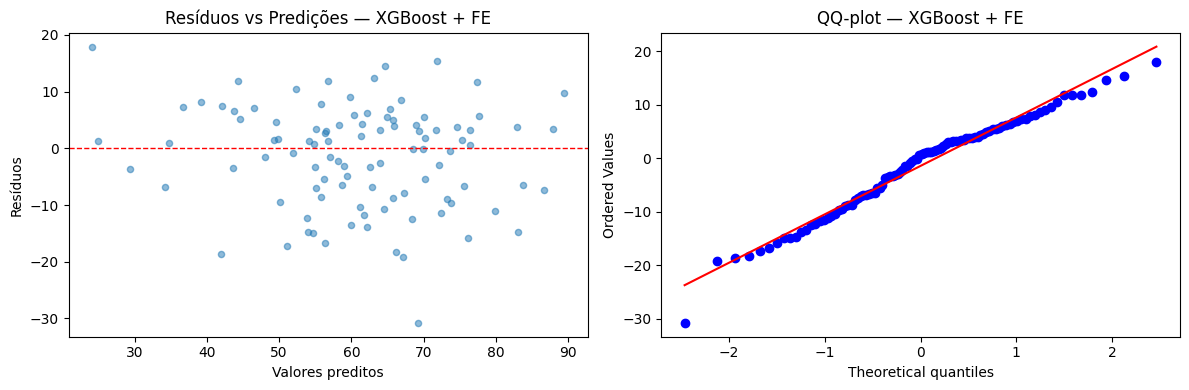

In [19]:
X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    df_fe, y, test_size=0.2, random_state=SEED
)

xgb_fe.fit(X_train_fe, y_train_fe)
y_pred_fe = xgb_fe.predict(X_test_fe)

print("=== XGBoost + FE — Test set ===")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test_fe, y_pred_fe)):.2f}")
print(f"MAE  : {mean_absolute_error(y_test_fe, y_pred_fe):.2f}")
print(f"R²   : {r2_score(y_test_fe, y_pred_fe):.3f}")

# Resíduos
residuals_fe = y_test_fe - y_pred_fe
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_pred_fe, residuals_fe, alpha=0.5, s=20)
axes[0].axhline(0, color="red", linestyle="--", linewidth=1)
axes[0].set_xlabel("Valores preditos")
axes[0].set_ylabel("Resíduos")
axes[0].set_title("Resíduos vs Predições — XGBoost + FE")

from scipy import stats
stats.probplot(residuals_fe, plot=axes[1])
axes[1].set_title("QQ-plot — XGBoost + FE")
plt.tight_layout()
plt.show()

O ganho mais expressivo foi no R² do CV (+0.078), o que indica que as features de interação estão capturando padrões reais. O modelo agora explica 67.5% da variância no cross-validation.

Além desse, obtive-se algumas melhorias no RMSE do teste (-0.11), MAE do teste (-0.15) e um leve aumento no R² do teste (+0.009). 

### Multicolinearidade e curva de aprendizado

VIF — features contínuas/ordinais:
               feature       VIF
1  target_audience_age  1.497684
0         text_density  1.492520
3    music_voice_ratio  1.006671
2     video_duration_s  1.006668


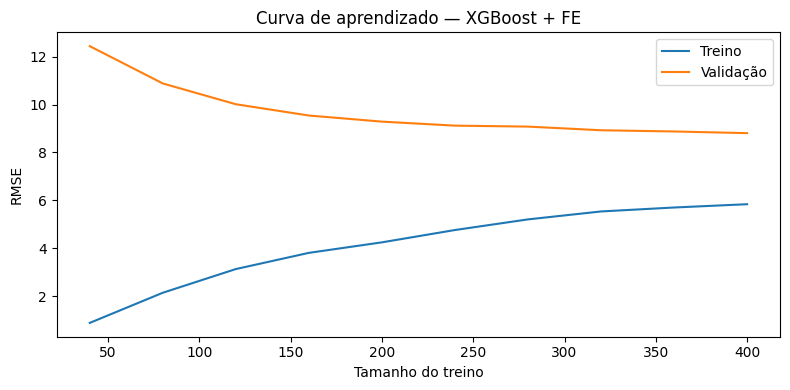

In [22]:
# VIF das features contínuas/ordinais (inalteradas)
X_transformed_fe = preprocessor_fe.fit_transform(df_fe)
n_bool_fe    = len(bool_features_fe)
n_nominal_fe = len(preprocessor_fe.named_transformers_["nominal"]
                   .get_feature_names_out(nominal_features_fe))

X_vif_fe = X_transformed_fe[:, n_bool_fe + n_nominal_fe:]
vif_df_fe = pd.DataFrame({
    "feature": ordinal_features_fe + numeric_features_fe,
    "VIF": [variance_inflation_factor(X_vif_fe, i) for i in range(X_vif_fe.shape[1])]
})
print("VIF — features contínuas/ordinais:")
print(vif_df_fe.sort_values("VIF", ascending=False).to_string())

# Curva de aprendizado
train_sizes, train_scores, val_scores = learning_curve(
    xgb_fe, df_fe, y,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=KFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

train_rmse_fe = -train_scores.mean(axis=1)
val_rmse_fe   = -val_scores.mean(axis=1)

plt.figure(figsize=(8, 4))
plt.plot(train_sizes, train_rmse_fe, label="Treino")
plt.plot(train_sizes, val_rmse_fe,   label="Validação")
plt.xlabel("Tamanho do treino")
plt.ylabel("RMSE")
plt.title("Curva de aprendizado — XGBoost + FE")
plt.legend()
plt.tight_layout()
plt.show()

Os resultados de VIF e da curva de aprendizado permaneceram semelhantes aos do modelo anterior, sem Feature Engineering. Isto é, variáveis numéricas sem colinearidade e a curva de aprendizado ainda descada a importância de uma maior quantidade de dados para a melhoria do modelo.

### Feature Importance

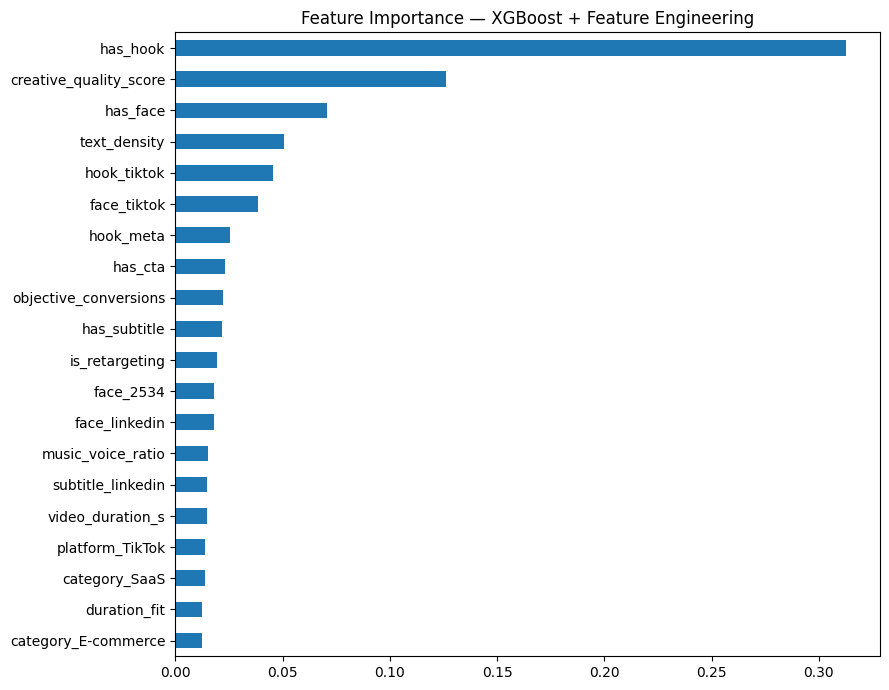


Top 10 features:
has_hook                  0.3128
creative_quality_score    0.1261
has_face                  0.0708
text_density              0.0508
hook_tiktok               0.0455
face_tiktok               0.0385
hook_meta                 0.0255
has_cta                   0.0233
objective_conversions     0.0221
has_subtitle              0.0220
dtype: float32


In [23]:
# Feature importance do modelo final com FE
prep_fe   = xgb_fe.named_steps["prep"]
model_fe  = xgb_fe.named_steps["model"]

ohe_names_fe = prep_fe.named_transformers_["nominal"] \
    .get_feature_names_out(nominal_features_fe).tolist()

all_feature_names_fe = (
    bool_features_fe +
    ohe_names_fe +
    ordinal_features_fe +
    numeric_features_fe
)

importances_fe = pd.Series(model_fe.feature_importances_, index=all_feature_names_fe)

importances_fe.sort_values().tail(20).plot(
    kind="barh", figsize=(9, 7),
    title="Feature Importance — XGBoost + Feature Engineering"
)
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
print(importances_fe.sort_values(ascending=False).head(10).round(4))

Nesse novo modelo, a presença de hook ainda é a mais importante para o modelo. Mas o ponto de destaque é que a nova feature `creative_quality_score` assumiu destaque sempre a segunda mais importante para o modelo. Essa feature combina alguns valores do criativo como o hook, face, subtitle e cta.

### Salvando o modelo

In [24]:
# Salva o modelo com feature engineering como final
joblib.dump(xgb_fe, "../models/final_model_fe.pkl")
print("Modelo final (com FE) salvo!")

Modelo final (com FE) salvo!
